<a href="https://colab.research.google.com/github/ppavon/teaching-materials/blob/main/notebooks/cao-latency/cao-latency-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fórmula de Cao (Best-Effort): percentiles de retardo de cola

**Asignatura:** Planificación y Gestión de Redes (3º Grado en Ingeniería Telemática)  
**Universidad:** Universidad Politécnica de Cartagena (UPCT, España)

Este notebook es un **recurso educativo** de la asignatura *Planificación y Gestión de Redes*.  
Permite experimentar de forma interactiva con la **fórmula de Cao** para estimar **percentiles altos del retardo de cola** (P99 y P99.9) en enlaces IP **best-effort**.

---

## 1) Problema que se estudia

Se desea estimar el **retardo de cola extremo** en un **único enlace IP best-effort**, en función de:

- Utilización del enlace $u \in (0,1)$  
- Capacidad del enlace $\beta$ (bps)  
- Tamaño medio de conexión $\gamma_b$ (bps por conexión)  
- Número medio de conexiones activas $c$

Ideas clave:

- Mayor **multiplexación estadística** $\Rightarrow$ menor retardo  
- Mayor **capacidad** $\Rightarrow$ menor retardo para el mismo $u$  
- Cuando $u \rightarrow 1$, los retardos crecen muy rápidamente  

---

## 2) Función logit

La **función logit** es una transformación matemática que convierte una probabilidad
$u \in (0,1)$ en un valor real no acotado.

En este modelo se utiliza el logit en base 2:

$$
\logit_2(u) = \log_2\left(\frac{u}{1-u}\right)
$$

Propiedades importantes:

- Está definida únicamente para $0 < u < 1$
- Es una función **estrictamente creciente**
- Cuando $u \rightarrow 0$, $\logit_2(u) \rightarrow -\infty$
- Cuando $u \rightarrow 1$, $\logit_2(u) \rightarrow +\infty$

Esta transformación es especialmente adecuada para modelar fenómenos que
**se disparan cerca de la saturación**, como el retardo en colas de red.

---

## 3) Modelo de Cao (2004)

La fórmula de Cao relaciona la utilización del enlace con un percentil alto del retardo:

$$
\logit_2(u)
=
o
+
(o_c + o_{\tau\delta}) \log_2(c)
+
o_{\tau\delta} \log_2(\gamma_b \, \delta)
+
o_w \left(-\log_2\left(-\log_2(w)\right)\right)
$$

donde:

- $u$: utilización del enlace  
- $\delta$: retardo (en segundos) asociado al percentil considerado  
- $w = \Pr\{\text{delay} \ge \delta\}$  
  - P99 $\Rightarrow w = 0.01$  
  - P99.9 $\Rightarrow w = 0.001$  
- $c$: número medio de conexiones activas  
- $\gamma_b$: tamaño medio de conexión (bps por conexión)  

---

## 4) Parámetros del modelo

Valores utilizados en este notebook (ajuste empírico de Cao):

- $o = -8.933$  
- $o_c = 0.420$  
- $o_{\tau\delta} = 0.444$  
- $o_w = 0.893$  

---

## 5) Aplicación en este notebook

Para cada capacidad del enlace $\beta$ y cada valor de utilización $u$:

1. Tráfico medio del enlace:

$$
\tau = u \, \beta
$$

2. Número medio de conexiones activas:

$$
c = \frac{u \, \beta}{\gamma_b}
$$

3. Se despeja el retardo $\delta$ a partir del modelo de Cao.

4. Se representa $\delta$ (en milisegundos) frente a la utilización $u$.

---

## 6) Objetivo didáctico

Comprender la relación entre:

$$
\text{utilización}
\;\; \leftrightarrow \;\;
\text{multiplexación}
\;\; \leftrightarrow \;\;
\text{retardo extremo}
$$

y analizar su impacto en la planificación de redes IP best-effort.


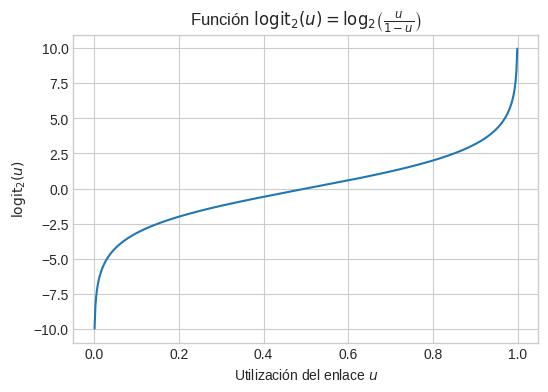

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de la función logit en base 2
def logit2(u):
    return np.log2(u / (1 - u))

# Rango de utilización (evitando 0 y 1)
u = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(6,4))
plt.plot(u, logit2(u))

plt.xlabel("Utilización del enlace $u$")
plt.ylabel(r"$\mathrm{logit}_2(u)$")
plt.title(r"Función $\mathrm{logit}_2(u) = \log_2\!\left(\frac{u}{1-u}\right)$")

plt.grid(True)
plt.show()



In [21]:
# ===== Celda 1: imports =====
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, clear_output


In [22]:
# ===== Celda 2: parámetros del modelo (según apuntes) =====
# Ver diapositivas de "Network simulation & overprovisioning requirements estimation"
# (Cao 2004): parámetros ajustados
O_HAT   = -8.933
OC_HAT  =  0.420
OTD_HAT =  0.444
OW_HAT  =  0.893

def logit2(u: np.ndarray) -> np.ndarray:
    """log2(u/(1-u)) para u en (0,1)."""
    return np.log2(u / (1.0 - u))


def cao_delay_seconds(u: np.ndarray, beta_bps: float, gamma_b_bps: float, w: float) -> np.ndarray:
    """
    Calcula delta (segundos) para cada u según el despeje del modelo de Cao.

    - u: array de utilizaciones (0..0.99)
    - beta_bps: capacidad del enlace (bps)
    - gamma_b_bps: tamaño medio de conexión (bps por conexión)
    - w: P(delay >= delta). Para P99: 0.01. Para P99.9: 0.001
    """
    u = np.asarray(u, dtype=float)

    # Evitar problemas numéricos en u=0 o u=1:
    # para u=0 dibujaremos delta=0 directamente.
    eps = 1e-12
    u_safe = np.clip(u, eps, 1.0 - eps)

    # c = (u * beta) / gamma_b
    c = (u_safe * beta_bps) / gamma_b_bps

    # Evitar log2(c) con c < 1 (poca interpretación física, pero numéricamente estable):
    # ponemos un mínimo suave.
    c_safe = np.clip(c, 1.0, None)

    # Termino de w:  -log2(-log2(w))
    w_term = (-np.log2(-np.log2(w)))

    rhs = (
        logit2(u_safe)
        - O_HAT
        - (OC_HAT + OTD_HAT) * np.log2(c_safe)
        - OTD_HAT * np.log2(gamma_b_bps)
        - OW_HAT * w_term
    )

    # o_{τδ} * log2(delta) = rhs  =>  log2(delta) = rhs / o_{τδ}
    log2_delta = rhs / OTD_HAT
    delta = 2.0 ** log2_delta  # seconds

    # Forzar delta=0 cuando u=0 exacto para la gráfica solicitada
    delta = np.where(u == 0.0, 0.0, delta)
    return delta


In [23]:
# ===== Celda 3: widgets (controles) claros y en vertical =====

import ipywidgets as widgets
from IPython.display import display

title = widgets.HTML(
    "<h2>Fórmula de Cao (Best-Effort): percentiles de retardo vs. utilización</h2>"
)

percentile = widgets.ToggleButtons(
    options=[("P99", "P99"), ("P99.9", "P99.9")],
    value="P99.9",
    description="Percentil:",
    style={"description_width": "140px"},
)

capacities_text = widgets.Text(
    value="1 10 40 100 400",
    description="Capacidades (Gbps):",
    placeholder="Ej: 1 10 40 100 400",
    layout=widgets.Layout(width="650px"),
    style={"description_width": "140px"},
)

# --- Tamaño medio de conexión: slider + entrada manual sincronizados ---
gamma_slider = widgets.FloatSlider(
    value=1.0,
    min=0.05,
    max=100.0,
    step=0.05,
    description="Tamaño medio conexión (Mbps):",
    readout=True,
    readout_format=".2f",
    style={"description_width": "240px"},
    layout=widgets.Layout(width="650px"),
)

gamma_text = widgets.BoundedFloatText(
    value=1.0,
    min=0.05,
    max=100.0,
    step=0.05,
    description="(valor exacto):",
    style={"description_width": "140px"},
    layout=widgets.Layout(width="300px"),
)

# Sincronizar ambos (frontend, instantáneo)
widgets.jslink((gamma_slider, "value"), (gamma_text, "value"))

gamma_box = widgets.HBox([gamma_slider, gamma_text])

# --- Límite eje Y: solo visualización (slider + entrada manual) ---
ymax_slider = widgets.FloatSlider(
    value=500.0,
    min=10.0,
    max=500.0,
    step=10.0,
    description="Límite eje Y (ms) [solo visualización]:",
    readout=True,
    readout_format=".0f",
    style={"description_width": "330px"},
    layout=widgets.Layout(width="650px"),
)

ymax_text = widgets.BoundedFloatText(
    value=500.0,
    min=10.0,
    max=500.0,
    step=10.0,
    description="(valor exacto):",
    style={"description_width": "140px"},
    layout=widgets.Layout(width="300px"),
)

widgets.jslink((ymax_slider, "value"), (ymax_text, "value"))

ymax_box = widgets.HBox([ymax_slider, ymax_text])

# --- Opción: recortar valores al máximo de visualización (para no “salirse”) ---
clip_checkbox = widgets.Checkbox(
    value=True,
    description="Recortar retardos al límite del eje Y (solo para visualización)",
)

btn = widgets.Button(
    description="Generar gráfica",
    button_style="primary",
    icon="line-chart",
    layout=widgets.Layout(width="220px")
)

out = widgets.Output()

sep = widgets.HTML("<hr style='margin:10px 0;'>")

ui = widgets.VBox([
    title,
    sep,
    percentile,
    sep,
    capacities_text,
    sep,
    gamma_box,
    sep,
    ymax_box,
    clip_checkbox,
    sep,
    btn,
    out
])

display(ui)


In [24]:
# ===== Celda 4: callback para dibujar =====

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

def parse_capacities_gbps(text: str):
    tokens = text.replace(",", " ").split()
    caps = []
    for t in tokens:
        try:
            caps.append(float(t))
        except ValueError:
            pass
    # quitar duplicados preservando orden
    seen = set()
    caps2 = []
    for c in caps:
        if c > 0 and c not in seen:
            seen.add(c)
            caps2.append(c)
    return caps2

def on_click(_):
    with out:
        clear_output(wait=True)

        caps_gbps = parse_capacities_gbps(capacities_text.value)
        if not caps_gbps:
            print("⚠️ No se han podido leer capacidades. Ejemplo válido: 1 10 40 100 400")
            return

        # u: 0%..99% en saltos de 1%
        u = np.arange(0.0, 1.0, 0.01)
        u = u[u <= 0.99]

        # percentil => w
        w = 0.01 if percentile.value == "P99" else 0.001

        # gamma_b en bps (valor sincronizado slider/text)
        gamma_b_bps = gamma_slider.value * 1e6

        # ymax (ms) solo visualización
        y_max_ms = ymax_slider.value

        plt.figure(figsize=(10, 5))

        for cap in caps_gbps:
            beta_bps = cap * 1e9
            delta_s = cao_delay_seconds(u, beta_bps, gamma_b_bps, w)
            delta_ms = 1e3 * delta_s

            # Opcional: recortar valores al límite de visualización
            if clip_checkbox.value:
                delta_ms = np.clip(delta_ms, 0.0, y_max_ms)

            plt.plot(100*u, delta_ms, label=f"{cap:g} Gbps")

        plt.xlabel("Utilización del enlace $u$ (%)")
        plt.ylabel(f"Retardo {percentile.value} (ms)")
        plt.title(rf"Cao best-effort — $\gamma_b$={gamma_slider.value:.2f} Mbps/conn")
        plt.grid(True)
        plt.ylim(0, y_max_ms)  # límite dinámico del eje Y (solo visualización)
        plt.legend()
        plt.show()

btn.on_click(on_click)

# Auto-ejecutar una primera vez
on_click(None)
